1. Importar librerias, cargar el data set y limpiarlo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajuste de tamaño
plt.rcParams['figure.figsize'] = (10, 6)

In [33]:
# 1. Cargar el dataset
df = pd.read_csv('Industrial_fault_detection.csv')

# 2. Eliminar las columnas que no nos sirven (Presión, Caudal, Voltaje, Corriente y sus FFT)
columnas_a_borrar = [col for col in df.columns if any(palabra in col for palabra in ['Pressure', 'Flow', 'Current', 'Voltage', 'Pres', 'Volt'])]
df_limpio = df.drop(columns=columnas_a_borrar)

# 3. Comprobar qué nos ha quedado y si hay valores nulos
print("Tamaño del dataset tras el filtro:", df_limpio.shape)
print("\nValores nulos por columna:")
print(df_limpio.isnull().sum())

Tamaño del dataset tras el filtro: (1000, 23)

Valores nulos por columna:
Temperature    0
Vibration      0
FFT_Temp_0     0
FFT_Vib_0      0
FFT_Temp_1     0
FFT_Vib_1      0
FFT_Temp_2     0
FFT_Vib_2      0
FFT_Temp_3     0
FFT_Vib_3      0
FFT_Temp_4     0
FFT_Vib_4      0
FFT_Temp_5     0
FFT_Vib_5      0
FFT_Temp_6     0
FFT_Vib_6      0
FFT_Temp_7     0
FFT_Vib_7      0
FFT_Temp_8     0
FFT_Vib_8      0
FFT_Temp_9     0
FFT_Vib_9      0
Fault_Type     0
dtype: int64


En esta primera parte  filtramos los datos segun los sensores que nos pueden interesar, retirando las columnas Pressure, Flow, Current, Voltage, Pres, Volt.

Además tambien comprobamos que no tenemos ningun valor NaN en las columnas deseadas.

2. Analisis de la variable Fault_Type

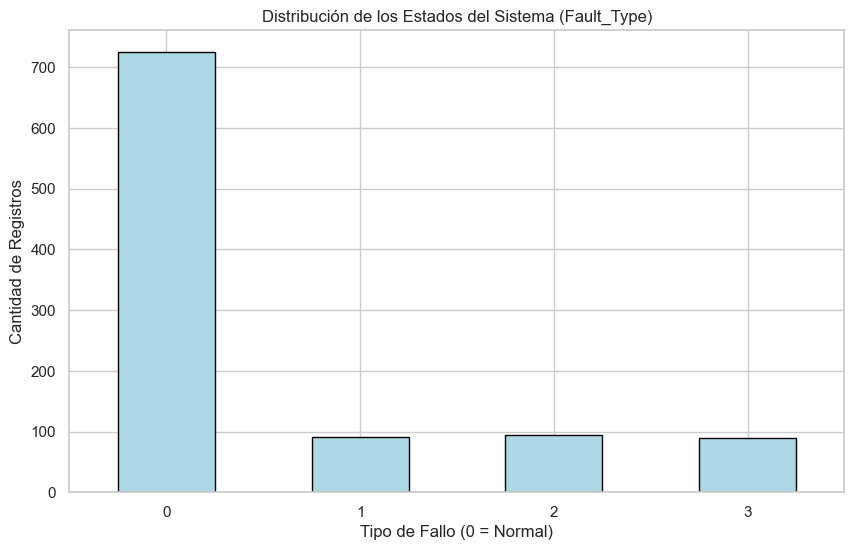


Porcentajes de cada clase:
Fault_Type
0    72.5
1     9.1
2     9.5
3     8.9
Name: proportion, dtype: float64


In [22]:
# 1. Contar cuántos datos hay de cada tipo de fallo y ordenarlos (0, 1, 2...)
conteos = df_limpio['Fault_Type'].value_counts().sort_index()

# 2. Dibujar el gráfico de barras
conteos.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Distribución de los Estados del Sistema (Fault_Type)')
plt.xlabel('Tipo de Fallo (0 = Normal)')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=0) 
plt.show()

# 3. Ver los porcentajes exactos en texto
print("\nPorcentajes de cada clase:")
print(df_limpio['Fault_Type'].value_counts(normalize=True).sort_index() * 100)

En este gráfico de barras se puede ver una clara asimetría hacia el estado 0, esto refuerza la viabilidad del data set ya que significa que en su mayoría no hay fallos, en un 72.5% del tiempo.

3. Estadisticas descriptivas: Vibración y temperatura

In [23]:
# Sacamos las estadísticas solo de los sensores físicos principales
sensores_brutos = ['Vibration', 'Temperature']
print(df_limpio[sensores_brutos].describe())

         Vibration  Temperature
count  1000.000000  1000.000000
mean      3.031611    75.005231
std       0.229013     2.589552
min       1.621016    45.642247
25%       2.889862    73.646389
50%       3.040625    75.024788
75%       3.183112    76.461058
max       3.784214    82.164581


Con estos datos podemos sacar información útil para la parte del hardware, como usar el minimo y maximo para elegir sensores que no colapsen por datos que excedan su capacidad.


4. Diagramas de caja y valores atípicos

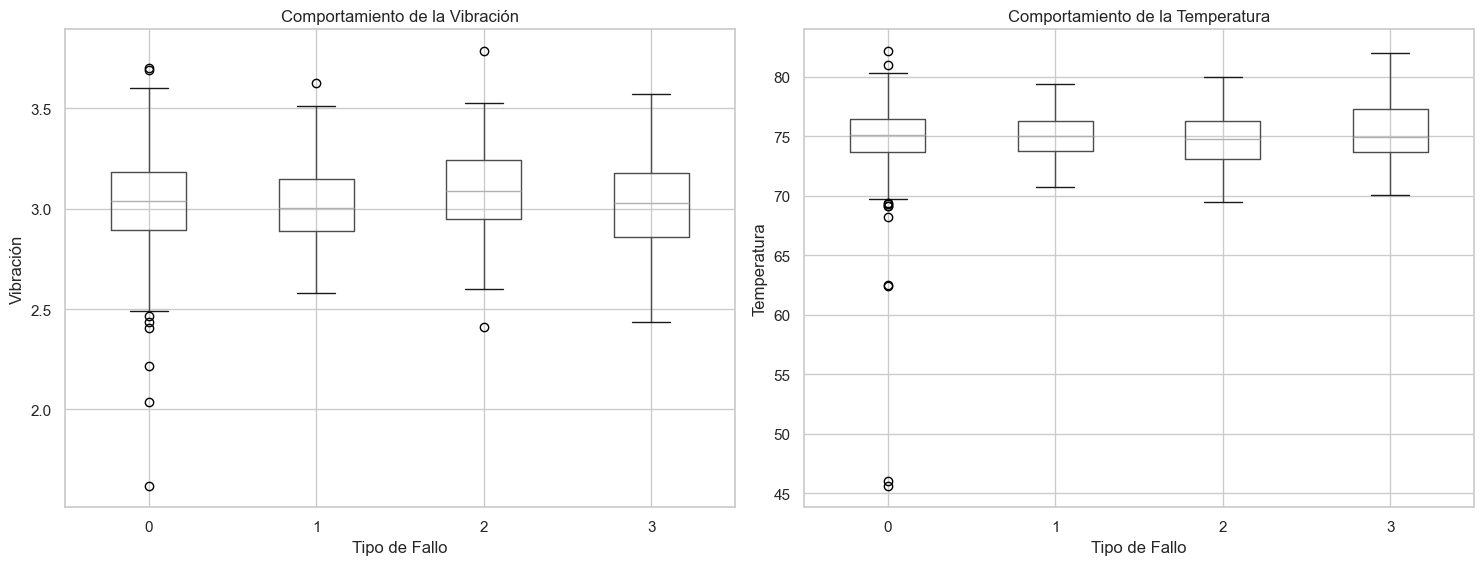

In [34]:
# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot de Vibración (agrupado por Fault_Type)
df_limpio.boxplot(column='Vibration', by='Fault_Type', ax=axes[0])
axes[0].set_title('Comportamiento de la Vibración')
axes[0].set_xlabel('Tipo de Fallo')
axes[0].set_ylabel('Vibración')

# Boxplot de Temperatura (agrupado por Fault_Type)
df_limpio.boxplot(column='Temperature', by='Fault_Type', ax=axes[1])
axes[1].set_title('Comportamiento de la Temperatura')
axes[1].set_xlabel('Tipo de Fallo')
axes[1].set_ylabel('Temperatura')

# Pandas pone un título general automático muy feo al usar 'by', esto lo quita:
plt.suptitle('') 

plt.tight_layout()
plt.show()

Aqui se pueden ver varios valores atípicos (los puntos), estos picos extremos representan eventos transitorios de alta energía los cuales serán fundamentales para que el modelo Random Forest pueda discriminar el estado de daño frente al ruido ambiental.

Data set 2

1. Cargar el data set y limpiarlo

In [17]:
# 1. Cargar el dataset
df2 = pd.read_csv('building_health_monitoring_dataset.csv')

# 2. Comprobar nulos ANTES de limpiar
print("Nulos antes de la limpieza:\n", df2.isnull().sum())

# 3. Eliminar las filas corruptas/nulas (simulando cortes de conexión del sensor)
df2_limpio = df2.dropna()

# 4. Comprobar cómo queda el dataset final
print("\nTamaño del dataset final listo para usar:", df2_limpio.shape)
df2

Nulos antes de la limpieza:
 Timestamp           0
Accel_X (m/s^2)    20
Accel_Y (m/s^2)    20
Accel_Z (m/s^2)    20
Strain (με)        20
Temp (°C)          20
Condition Label     0
dtype: int64

Tamaño del dataset final listo para usar: (904, 7)


,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label
0,2025-04-19 00:00:00,0.149014,0.419807,9.742482,61.843849,23.704760,0
1,2025-04-19 00:00:01,-0.041479,0.277390,9.795548,82.792300,24.953195,0
2,2025-04-19 00:00:02,0.194307,0.017889,9.730758,91.727889,25.027025,0
3,2025-04-19 00:00:03,0.456909,-0.194081,9.779204,137.753753,25.708946,0
4,2025-04-19 00:00:04,-0.070246,0.209467,9.620639,111.131062,22.949712,0
...,...,...,...,...,...,...,...
995,2025-04-19 00:16:35,0.113365,0.321045,9.817748,130.569152,24.926552,1
996,2025-04-19 00:16:36,1.295021,-0.007956,9.835775,118.443764,27.608616,2
997,2025-04-19 00:16:37,0.192253,-0.264562,9.685824,93.594044,29.669365,0
998,2025-04-19 00:16:38,-0.171354,-0.048920,9.843418,132.867563,26.212054,0


En esta primera parte limpiamos el data set de valores NaN.

2. Analisis de la variable Condition Label

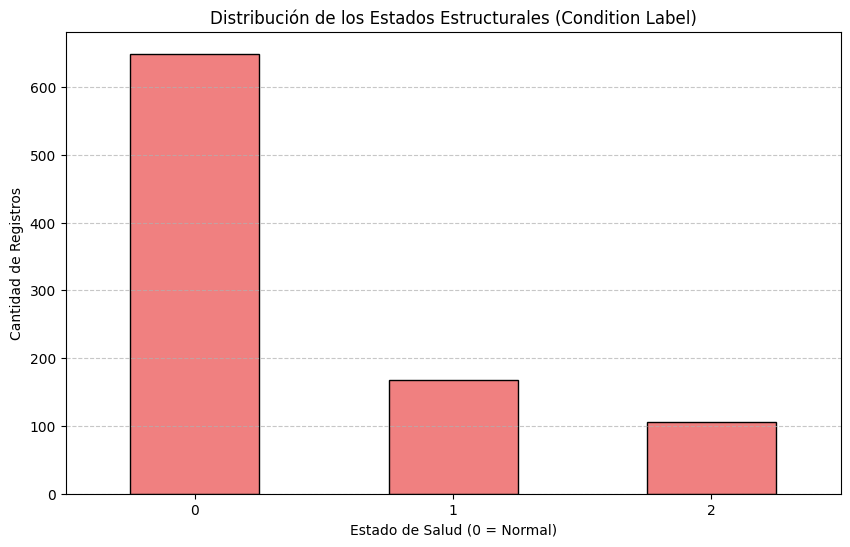


Porcentajes de cada estado:
Condition Label
0    70.314193
1    18.201517
2    11.484290
Name: proportion, dtype: float64


In [11]:
# 1. Contar cuántos datos hay de cada estado de salud estructural
conteos = df2_limpio['Condition Label'].value_counts().sort_index()

# 2. Dibujar el gráfico de barras
conteos.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Distribución de los Estados Estructurales (Condition Label)')
plt.xlabel('Estado de Salud (0 = Normal)')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Ver porcentajes
print("\nPorcentajes de cada estado:")
print(df2_limpio['Condition Label'].value_counts(normalize=True).sort_index() * 100)

El gráfico de barras de la variable objetivo (Condition Label) nos permite evaluar la proporción de datos sanos frente a datos anómalos. Al igual que en entornos industriales, observar la distribución real nos advertirá de posibles sesgos en el dataset, lo cual determinará si necesitaremos aplicar técnicas de balanceo (como oversampling o undersampling) antes de entrenar nuestro algoritmo de Random Forest para la detección de daño.

3. Estadística Descriptiva

In [29]:
# Sacamos las estadísticas de TODOS los sensores físicos (añadido Strain)
sensores_brutos_df2 = [
    'Accel_X (m/s^2)', 
    'Accel_Y (m/s^2)', 
    'Accel_Z (m/s^2)', 
    'Strain (με)',       
    'Temp (°C)'
]

print(df2_limpio[sensores_brutos_df2].describe())

       Accel_X (m/s^2)  Accel_Y (m/s^2)  Accel_Z (m/s^2)  Strain (με)  \
count       904.000000       904.000000       904.000000   904.000000   
mean          0.105587         0.016886         9.812302   111.888823   
std           0.341202         0.297848         0.097370    28.657579   
min          -0.795291        -0.882117         9.508049    41.860236   
25%          -0.139457        -0.183206         9.747016    92.533711   
50%           0.084314         0.012629         9.810229   108.960912   
75%           0.302895         0.217719         9.875345   127.944820   
max           1.337972         0.941325        10.202624   224.861859   

        Temp (°C)  
count  904.000000  
mean    25.033823  
std      1.518137  
min     20.244361  
25%     24.023528  
50%     25.059944  
75%     26.051349  
max     29.838898  


La tabla descriptiva confirma la validez física del dataset. Resulta especialmente interesante observar la media del eje Z del acelerómetro (Accel_Z), que refleja la aceleración constante de la gravedad terrestre ($\approx 9.8 \, m/s^2$). Esto corrobora que los datos simulan perfectamente el comportamiento de un sensor inercial como nuestro MPU6050 en reposo.

Además, al incorporar la variable Strain a la estadística, podemos observar su rango dinámico (mínimos y máximos), lo que nos permitirá calibrar la sensibilidad del sensor piezoeléctrico en el código de Arduino para que no sature ante los impactos más severos. Finalmente, los rangos de temperatura máxima y mínima nos permiten establecer los umbrales operativos.

4. Boxplots y Valores Atípicos.

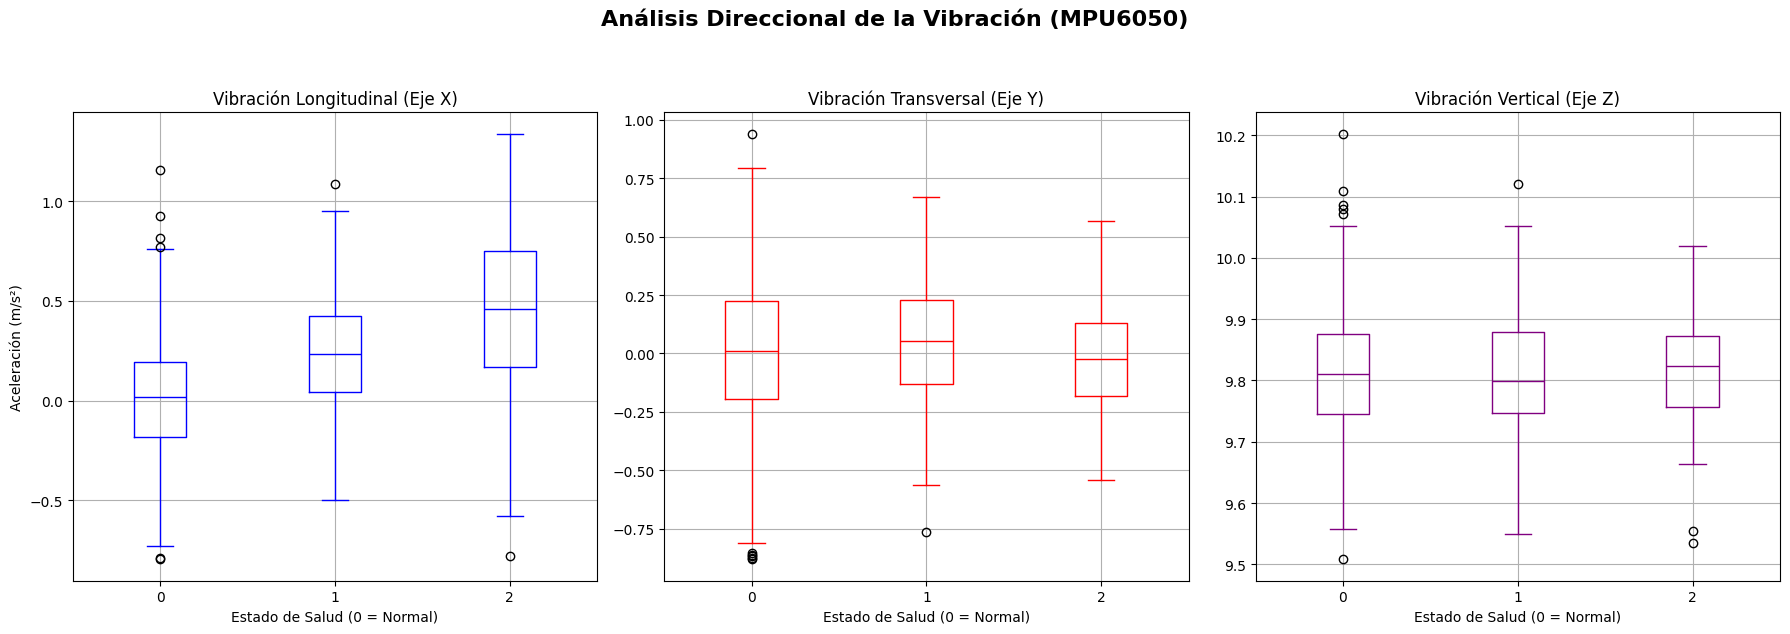

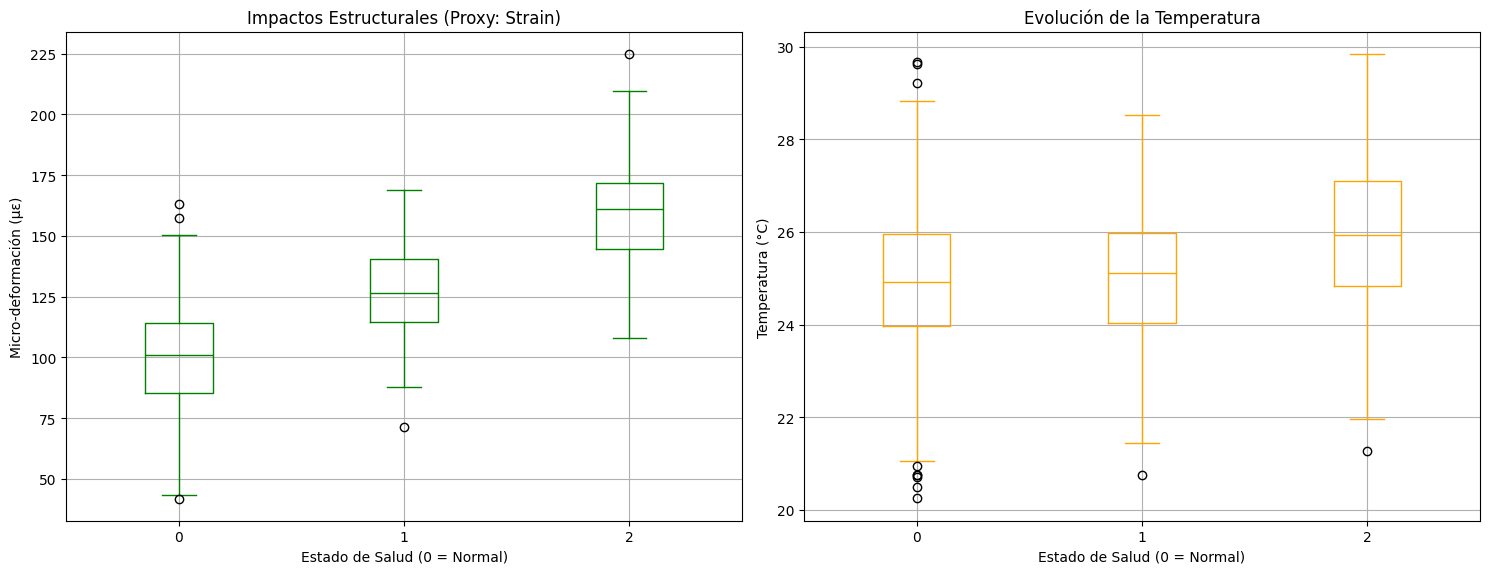

In [25]:
# Creamos una sola figura ancha con 3 gráficos alineados (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot Eje X (Longitudinal)
df2_limpio.boxplot(column='Accel_X (m/s^2)', by='Condition Label', ax=axes[0], color='blue')
axes[0].set_title('Vibración Longitudinal (Eje X)')
axes[0].set_xlabel('Estado de Salud (0 = Normal)')
axes[0].set_ylabel('Aceleración (m/s²)')

# 2. Boxplot Eje Y (Transversal)
df2_limpio.boxplot(column='Accel_Y (m/s^2)', by='Condition Label', ax=axes[1], color='red')
axes[1].set_title('Vibración Transversal (Eje Y)')
axes[1].set_xlabel('Estado de Salud (0 = Normal)')
# No le ponemos ylabel para no saturar el gráfico, ya se entiende del primero

# 3. Boxplot Eje Z (Vertical / Gravedad)
df2_limpio.boxplot(column='Accel_Z (m/s^2)', by='Condition Label', ax=axes[2], color='purple')
axes[2].set_title('Vibración Vertical (Eje Z)')
axes[2].set_xlabel('Estado de Salud (0 = Normal)')

# Ajustes estéticos para que quede de nivel "matrícula"
plt.suptitle('Análisis Direccional de la Vibración (MPU6050)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot de Deformación (Nuestro proxy para el Piezoeléctrico)
df2_limpio.boxplot(column='Strain (με)', by='Condition Label', ax=axes[0], color='green')
axes[0].set_title('Impactos Estructurales (Proxy: Strain)')
axes[0].set_xlabel('Estado de Salud (0 = Normal)')
axes[0].set_ylabel('Micro-deformación (με)')

# 2. Boxplot de Temperatura (Nuestro Termopar MAX6675)
df2_limpio.boxplot(column='Temp (°C)', by='Condition Label', ax=axes[1], color='orange')
axes[1].set_title('Evolución de la Temperatura')
axes[1].set_xlabel('Estado de Salud (0 = Normal)')
axes[1].set_ylabel('Temperatura (°C)')

# Limpiar el título automático de pandas y ajustar márgenes
plt.suptitle('') 
plt.tight_layout()
plt.show()

Dividir la vibración en sus tres componentes ortogonales (X, Y, Z) ofrece una ventaja fundamental respecto al análisis unidimensional. Los diagramas de caja nos revelan que la aparición de valores atípicos no se distribuye de manera uniforme en todos los ejes ante una anomalía. Dependiendo de la naturaleza del fallo, el incremento de energía vibratoria se concentrará en un eje específico. Físicamente, esto nos permitirá instruir al Random Forest para identificar no solo si existe un daño, sino la direccionalidad del impacto o la alteración estructural.